# Inflation Forecasting with FRED-MD Data

Forecasts **1-month-ahead annualized PCE inflation (PCEPI)** using FRED-MD monthly vintages.

## Cell 1 — Setup, Imports & Helper Functions

In [1]:
import sys, os, datetime
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from fred_md_utils import (
    configure_plots, default_paths, get_splits,
    load_fred_md_file, apply_fred_md_transforms,
    TEST_START, VAL_START,
)

configure_plots()
VINTAGE_DIR, RESULTS_DIR = default_paths()

print("Vintage dir :", os.path.abspath(VINTAGE_DIR))
print("Vintage dir exists:", os.path.isdir(VINTAGE_DIR))

# ______________________________________________________________
# Tuning Parameters:
# ______________________________________________________________
N_LAGS = 2          # lagged months added as features (0 = single-snapshot)
ROLLING_WINDOW = 60  # months of training history used for fitting (0 = all history)
CV_FOLDS = 5
PARAM_GRID = {
    'alpha':    [1e-5, 1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.5, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7],
}
TOP_K_FEATURES = 80   # SelectKBest pre-filter; reduces p/n ratio before ElasticNet
USE_ENET_CV = True    # True = ElasticNetCV (alpha-path); False = GridSearchCV


Vintage dir : /home/lukeholmes/2025-2026/ML/final-project/Macro-Econ-ML/notebooks/data
Vintage dir exists: True


In [2]:
import warnings
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------------------------
# Model
# ---------------------------------------------------------------------------

class InflationForecaster:
    """ElasticNet forecaster for inflation time series.

    Pipeline: RobustScaler -> SelectKBest(f_regression, k=top_k) -> ElasticNet(CV).

    - SelectKBest keeps only the top-k univariately-correlated features, which
      drops the effective p/n ratio and prevents L1 from zeroing everything.
    - ElasticNetCV uses a warm-start regularization path and is far more stable
      than GridSearchCV at small n. Set use_enet_cv=False to fall back to the
      old GridSearchCV behavior for comparison.
    """

    def __init__(self, random_state=42, top_k_features=None, use_enet_cv=None):
        self.random_state = random_state
        self.top_k_features = top_k_features if top_k_features is not None else TOP_K_FEATURES
        self.use_enet_cv = use_enet_cv if use_enet_cv is not None else USE_ENET_CV
        self.model = None
        self.best_params = None

    def _build_pipeline(self, estimator):
        # Cap k at n_features at fit-time via 'all' fallback handled by SelectKBest
        return Pipeline([
            ('scaler', RobustScaler()),
            ('select', SelectKBest(score_func=f_regression, k=self.top_k_features)),
            ('model', estimator),
        ])

    def _get_param_grid(self):
        return {f'model__{k}': v for k, v in PARAM_GRID.items()}

    def train(self, X_train, y_train, tune_hyperparameters=True, cv_folds=None):
        if cv_folds is None:
            cv_folds = CV_FOLDS

        # Cap k at available feature count
        k = min(self.top_k_features, X_train.shape[1])

        if self.use_enet_cv:
            print(f"Training ElasticNetCV (alpha-path) with SelectKBest(k={k})...")
            tscv = TimeSeriesSplit(n_splits=cv_folds)
            enet_cv = ElasticNetCV(
                l1_ratio=PARAM_GRID['l1_ratio'],
                n_alphas=100,
                cv=tscv,
                max_iter=100000,
                random_state=self.random_state,
                n_jobs=-1,
                selection='cyclic',
            )
            pipe = Pipeline([
                ('scaler', RobustScaler()),
                ('select', SelectKBest(score_func=f_regression, k=k)),
                ('model', enet_cv),
            ])
            pipe.fit(X_train, y_train)
            self.model = pipe
            fitted = pipe.named_steps['model']
            self.best_params = {
                'alpha': float(fitted.alpha_),
                'l1_ratio': float(fitted.l1_ratio_),
            }
            print(f"Best parameters: {self.best_params}")
        elif tune_hyperparameters:
            print(f"Tuning ElasticNet hyperparameters with GridSearchCV + SelectKBest(k={k})...")
            tscv = TimeSeriesSplit(n_splits=cv_folds)
            pipe = Pipeline([
                ('scaler', RobustScaler()),
                ('select', SelectKBest(score_func=f_regression, k=k)),
                ('model', ElasticNet(random_state=self.random_state, max_iter=100000)),
            ])
            grid_search = GridSearchCV(
                pipe,
                self._get_param_grid(),
                cv=tscv,
                scoring='neg_mean_squared_error',
                n_jobs=-1,
                verbose=1,
            )
            grid_search.fit(X_train, y_train)
            self.model = grid_search.best_estimator_
            self.best_params = {k2.replace('model__', ''): v for k2, v in grid_search.best_params_.items()}
            print(f"Best parameters: {self.best_params}")
            print(f"Best CV score (RMSE): {np.sqrt(-grid_search.best_score_):.4f}")
        else:
            print("Training ElasticNet with default parameters...")
            pipe = Pipeline([
                ('scaler', RobustScaler()),
                ('select', SelectKBest(score_func=f_regression, k=k)),
                ('model', ElasticNet(random_state=self.random_state, max_iter=100000)),
            ])
            pipe.fit(X_train, y_train)
            self.model = pipe
        return self

    def predict(self, X):
        if self.model is None:
            raise ValueError("Model must be trained before making predictions")
        return self.model.predict(X)

    def evaluate(self, X_test, y_test):
        y_pred = self.predict(X_test)
        metrics = {
            'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
            'mae': mean_absolute_error(y_test, y_pred),
            'r2': r2_score(y_test, y_pred),
            'mape': np.mean(np.abs((y_test - y_pred) / (y_test + 1e-10))) * 100,
        }
        return metrics, y_pred

    def get_feature_importance(self, feature_names):
        """Return |coef| for all original features; features dropped by SelectKBest get 0."""
        if self.model is None:
            raise ValueError("Model must be trained first")
        estimator = self.model.named_steps['model']
        selector = self.model.named_steps.get('select', None)
        if hasattr(estimator, 'coef_'):
            coef = estimator.coef_
        elif hasattr(estimator, 'feature_importances_'):
            coef = estimator.feature_importances_
        else:
            return None

        # Map back to the full feature set (zeros for features dropped by SelectKBest)
        full = np.zeros(len(feature_names), dtype=float)
        if selector is not None:
            support = selector.get_support()
            full[support] = coef
        else:
            full[:len(coef)] = coef

        return pd.DataFrame({
            'feature': feature_names,
            'importance': np.abs(full),
            'coefficient': full,
        }).sort_values('importance', ascending=False)


## Cell 2 — Data Loading

In [3]:
# Load vintage + build train/val/test splits via shared helper
vintage_file, X_train, y_train, X_val, y_val, X_test, y_test, feature_names = get_splits(
    VINTAGE_DIR, horizon=1, n_lags=N_LAGS,
)

print(f"\nTrain  samples : {len(X_train)}  features: {len(feature_names)}")
print(f"  Date range   : {X_train.index.min().date()} -> {X_train.index.max().date()}")
print(f"\nVal    samples : {len(X_val)}")
print(f"  Date range   : {X_val.index.min().date()} -> {X_val.index.max().date()}")
print(f"\nTest   samples : {len(X_test)}")
if len(X_test):
    print(f"  Date range   : {X_test.index.min().date()} -> {X_test.index.max().date()}")


  2026-04-MD.csv: URL returned HTML — vintage not yet published
Already have 2026-03-MD.csv

Dataset summary (PCEPI first-log-diff target, 1-month-ahead):
  Train :  742 obs  1959-03-01 -> 2020-12-01
  Val   :   36 obs  2021-01-01 -> 2023-12-01
  Test  :   24 obs  2024-01-01 -> 2025-12-01
  Features: 378 (126 base × 3 time steps)

Train  samples : 742  features: 378
  Date range   : 1959-03-01 -> 2020-12-01

Val    samples : 36
  Date range   : 2021-01-01 -> 2023-12-01

Test   samples : 24
  Date range   : 2024-01-01 -> 2025-12-01


In [4]:
# Load raw (transformed) vintage file to inspect PCEPI growth series
df_train_full, tcodes = load_fred_md_file(vintage_file)

# Show tcodes for key series
key_series = ['PCEPI', 'CPIAUCSL', 'UNRATE', 'FEDFUNDS', 'TB3MS', 'GS10', 'INDPRO', 'HOUST']
tcode_info = {s: tcodes.get(s, 'N/A') for s in key_series if s in tcodes or s in df_train_full.columns}
tcode_df = pd.DataFrame(list(tcode_info.items()), columns=['Series', 'TCode'])
tcode_descriptions = {
    1: 'No transform', 2: '1st diff', 3: '2nd diff',
    4: 'Log', 5: 'Log 1st diff x100', 6: 'Log 1st diff x100', 7: 'Delta pct chg x100'
}
tcode_df['Transform'] = tcode_df['TCode'].map(lambda x: tcode_descriptions.get(int(x), str(x)) if x != 'N/A' else 'N/A')
print("Transformation codes for key series:")
print(tcode_df.to_string(index=False))


print("\nLag structure: y[t] = PCEPI growth at t+1 (1-month-ahead forecast)")
print(f"  Features cover: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"  y[t] covers   : {y_train.index.min().date()} to {y_train.index.max().date()}")

Transformation codes for key series:
  Series  TCode         Transform
   PCEPI    6.0 Log 1st diff x100
CPIAUCSL    6.0 Log 1st diff x100
  UNRATE    2.0          1st diff
FEDFUNDS    2.0          1st diff
   TB3MS    2.0          1st diff
    GS10    2.0          1st diff
  INDPRO    5.0 Log 1st diff x100
   HOUST    4.0               Log

Lag structure: y[t] = PCEPI growth at t+1 (1-month-ahead forecast)
  Features cover: 1959-03-01 to 2020-12-01
  y[t] covers   : 1959-03-01 to 2020-12-01


## Cell 4 — Exploratory Data Analysis

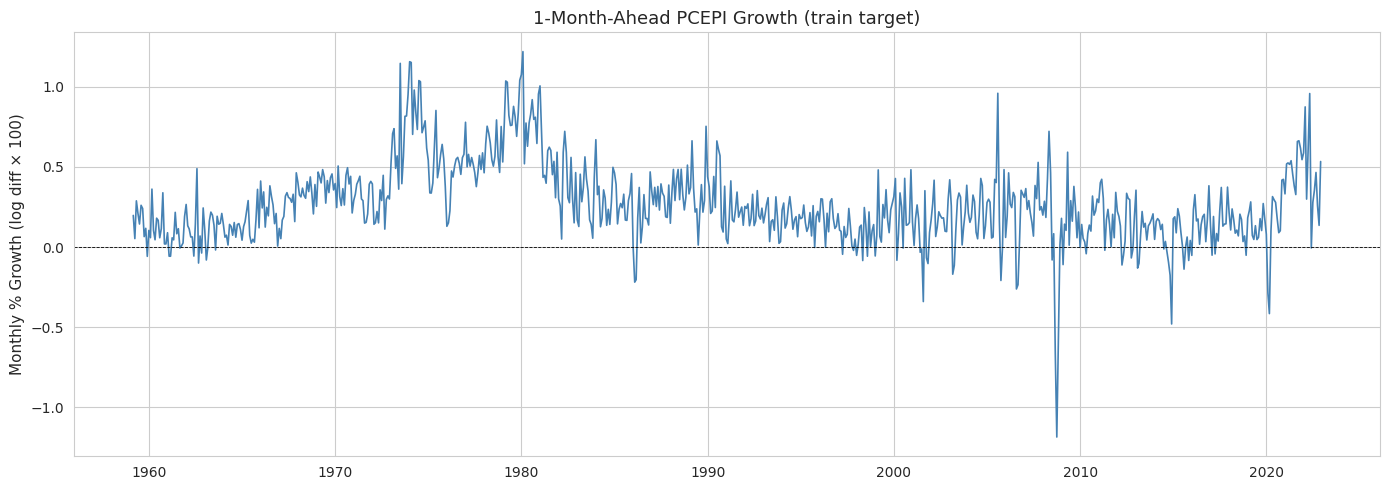

Top 15 features correlated with 1-month-ahead PCEPI growth:
TB3SMFFM         0.471
TB3SMFFM_lag1    0.459
TB3SMFFM_lag2    0.448
TB6SMFFM         0.444
TB6SMFFM_lag1    0.434
AAAFFM           0.431
AAAFFM_lag1      0.424
ACOGNO           0.419
TB6SMFFM_lag2    0.418
AAAFFM_lag2      0.412
COMPAPFFx        0.397
T10YFFM_lag1     0.397
T10YFFM          0.396
BUSINVx          0.392


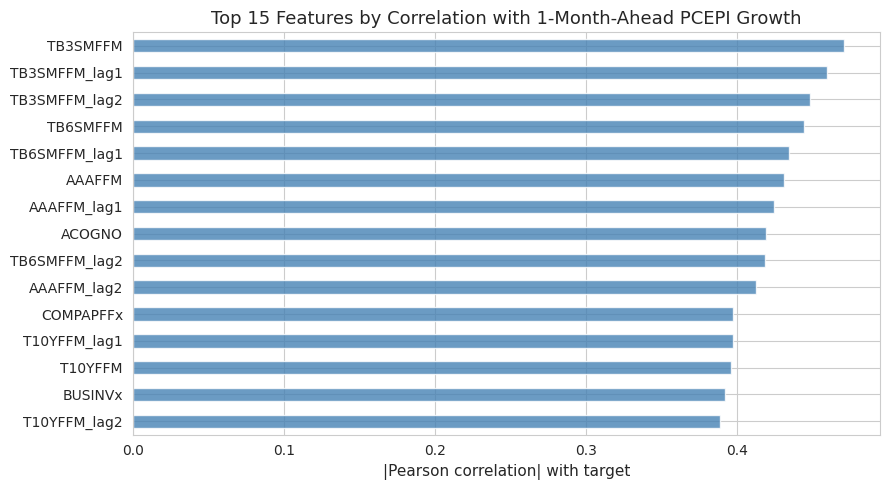

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

# --- PCEPI 1-month-ahead target over time ---
ax.plot(y_train.index, y_train.values, linewidth=1.2, color='steelblue')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_title('1-Month-Ahead PCEPI Growth (train target)')
ax.set_ylabel('Monthly % Growth (log diff × 100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
plt.show()

# --- Top 15 features correlated with target ---
corr = X_train.corrwith(y_train).abs().dropna().sort_values(ascending=False)
print("Top 14 features correlated with 1-month-ahead PCEPI growth:")
print(corr.head(14).round(3).to_string())

top_corr = corr.head(15)
if len(top_corr) > 0:
    fig2, ax2 = plt.subplots(figsize=(9, 5))
    top_corr.plot(kind='barh', ax=ax2, color='steelblue', alpha=0.8)
    ax2.set_xlabel('|Pearson correlation| with target')
    ax2.set_title('Top 15 Features by Correlation with 1-Month-Ahead PCEPI Growth')
    ax2.invert_yaxis()
    fig2.tight_layout()
    plt.show()
else:
    print("No valid correlations computed (all NaN).")

## Cell 5 — Train ElasticNet

Rolling window: fitting on last 60 months (2016-01-01 → 2020-12-01), CV folds: 5
Training ElasticNetCV (alpha-path) with SelectKBest(k=80)...
Best parameters: {'alpha': 0.27938999728290836, 'l1_ratio': 0.1}


TimeSeriesSplit CV results (ElasticNet, best params):
 fold  n_val     rmse      mae        r2
    1     10 0.176764 0.139614 -0.514640
    2     10 0.100877 0.082900 -0.533353
    3     10 0.095336 0.079802  0.046888
    4     10 0.137562 0.080002  0.041964
    5     10 0.247436 0.213790 -0.148683

Mean CV RMSE: 0.1516  |  Mean R²: -0.2216
Best hyperparams: {'alpha': 0.27938999728290836, 'l1_ratio': 0.1}


/home/lukeholmes/2025-2026/ML/final-project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


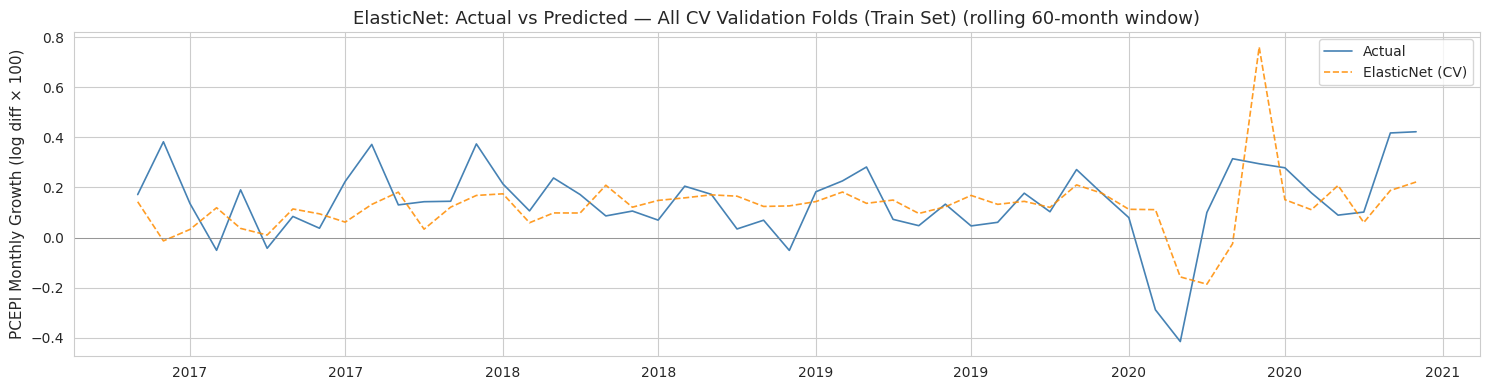

In [6]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Rolling window: restrict training data to most recent ROLLING_WINDOW months.
# Short windows let the model adapt to recent inflation regimes (Cleveland Fed insight).
if ROLLING_WINDOW > 0:
    X_train_fit = X_train.iloc[-ROLLING_WINDOW:]
    y_train_fit = y_train.iloc[-ROLLING_WINDOW:]
    cv_folds_fit = min(CV_FOLDS, max(2, ROLLING_WINDOW // 5))
    print(f"Rolling window: fitting on last {ROLLING_WINDOW} months "
          f"({X_train_fit.index.min().date()} → {X_train_fit.index.max().date()}), "
          f"CV folds: {cv_folds_fit}")
else:
    X_train_fit = X_train
    y_train_fit = y_train
    cv_folds_fit = CV_FOLDS

# --- Train ElasticNet with TimeSeriesSplit CV ---
elasticnet = InflationForecaster(random_state=42)
elasticnet.train(X_train_fit, y_train_fit, tune_hyperparameters=True, cv_folds=cv_folds_fit)

# --- Cross-validation fold performance ---
tscv = TimeSeriesSplit(n_splits=cv_folds_fit)
fold_metrics = []
all_val_dates = []
all_val_actual = []
all_val_pred = []

from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import ElasticNet
from sklearn.feature_selection import SelectKBest, f_regression

best_alpha    = elasticnet.best_params.get('alpha', 0.1)
best_l1_ratio = elasticnet.best_params.get('l1_ratio', 0.5)
X_arr = X_train_fit.values
y_arr = y_train_fit.values

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_arr)):
    scaler = RobustScaler()
    Xtr_s = scaler.fit_transform(X_arr[tr_idx])
    Xval_s = scaler.transform(X_arr[val_idx])
    # Match pipeline: SelectKBest pre-filter with same k used in training
    k_fold = min(TOP_K_FEATURES, Xtr_s.shape[1])
    sel = SelectKBest(score_func=f_regression, k=k_fold).fit(Xtr_s, y_arr[tr_idx])
    Xtr  = sel.transform(Xtr_s)
    Xval = sel.transform(Xval_s)
    ytr, yval = y_arr[tr_idx], y_arr[val_idx]

    m = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=100000, random_state=42)
    m.fit(Xtr, ytr)
    pred = m.predict(Xval)

    fold_metrics.append({
        'fold':  fold + 1,
        'n_val': len(yval),
        'rmse':  np.sqrt(mean_squared_error(yval, pred)),
        'mae':   mean_absolute_error(yval, pred),
        'r2':    r2_score(yval, pred),
    })

    all_val_dates.extend(X_train_fit.index[val_idx])
    all_val_actual.extend(yval)
    all_val_pred.extend(pred)

cv_df = pd.DataFrame(fold_metrics)
print('TimeSeriesSplit CV results (ElasticNet, best params):')
print(cv_df.to_string(index=False))
print(f'\nMean CV RMSE: {cv_df["rmse"].mean():.4f}  |  Mean R²: {cv_df["r2"].mean():.4f}')
print(f'Best hyperparams: {elasticnet.best_params}')

# --- Plot predictions across all CV folds ---
all_val_dates  = pd.DatetimeIndex(all_val_dates)
all_val_actual = np.array(all_val_actual)
all_val_pred   = np.array(all_val_pred)

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(all_val_dates, all_val_actual, '-',  label='Actual',          linewidth=1.2, color='steelblue')
ax.plot(all_val_dates, all_val_pred,   '--', label='ElasticNet (CV)', linewidth=1.2, alpha=0.85, color='darkorange')
ax.axhline(0, color='grey', linewidth=0.5)
title_suffix = f' (rolling {ROLLING_WINDOW}-month window)' if ROLLING_WINDOW > 0 else ''
ax.set_title(f'ElasticNet: Actual vs Predicted — All CV Validation Folds (Train Set){title_suffix}')
ax.set_ylabel('PCEPI Monthly Growth (log diff × 100)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()


Out-of-Sample Test Performance (ElasticNet, held-out 15%):
  Test date range: 2024-01-01 to 2025-12-01
  n observations : 24
  RMSE : 0.1323
  MAE  : 0.1124
  R²   : -0.7964
  MAPE : 152.79%

  [Naive constant-mean baseline]  RMSE=0.1283  R²=-0.6886
  ElasticNet RMSE vs naive      : -0.0040  (positive = beats naive)
Vintage anchor (latest data)  : 2026-02-01
Chain start (last test obs)   : 2025-12-01
Current month                 : 2026-04-01
Total forecast steps          : 4



  LATEST FORECASTS
  Vintage anchor: 2026-02-01  |  Chain start: 2025-12-01
  Jan 2026 (step  1) (data-anchored): +0.1235% monthly  (+2.64% YoY)
  Feb 2026 (step  2) (data-anchored): +0.1307% monthly  (+2.52% YoY)
  Mar 2026 (step  3) (chained)     : +0.1389% monthly  (+2.65% YoY)
  Apr 2026 (step  4) (chained)     : +0.1240% monthly  (+2.60% YoY)


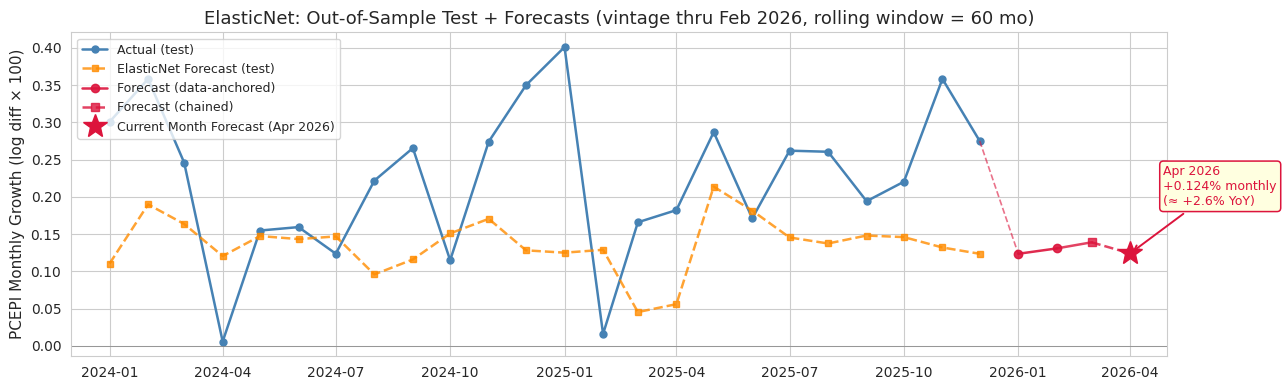

In [7]:
y_test_pred = np.array([])
if len(X_test) == 0:
    print('WARNING: No out-of-sample test observations available.')
else:
    # Align test features to training feature set
    test_cols = [c for c in feature_names if c in X_test.columns]
    X_test_aligned = X_test[test_cols]

    test_metrics, y_test_pred = elasticnet.evaluate(X_test_aligned, y_test)

    # --- Naive constant-mean baseline (helps interpret R^2 at small n_test) ---
    y_train_mean = y_train_fit.mean()
    naive_pred = np.full_like(y_test.values, fill_value=y_train_mean, dtype=float)
    naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
    naive_r2   = r2_score(y_test, naive_pred)

    print(f'Out-of-Sample Test Performance (ElasticNet, held-out 15%):')
    print(f'  Test date range: {X_test.index.min().date()} to {X_test.index.max().date()}')
    print(f'  n observations : {len(X_test)}')
    print(f'  RMSE : {test_metrics["rmse"]:.4f}')
    print(f'  MAE  : {test_metrics["mae"]:.4f}')
    print(f'  R²   : {test_metrics["r2"]:.4f}')
    print(f'  MAPE : {test_metrics["mape"]:.2f}%')
    print(f'\n  [Naive constant-mean baseline]  RMSE={naive_rmse:.4f}  R\u00b2={naive_r2:.4f}')
    print(f'  ElasticNet RMSE vs naive      : {(naive_rmse - test_metrics["rmse"]):+.4f}  (positive = beats naive)')

# ---------------------------------------------------------------------------
# Build raw data and feature matrix from vintage CSV
# ---------------------------------------------------------------------------
import warnings

raw_all = pd.read_csv(str(vintage_file), header=None)
headers_raw   = raw_all.iloc[0].tolist()
tcode_row_raw = raw_all.iloc[1].tolist()
tcodes_raw = {}
for h, t in zip(headers_raw[1:], tcode_row_raw[1:]):
    try:
        tcodes_raw[str(h)] = float(t)
    except (ValueError, TypeError):
        pass
df_raw2 = raw_all.iloc[2:].copy()
df_raw2.columns = headers_raw
df_raw2 = df_raw2.reset_index(drop=True)
dc = df_raw2.columns[0]
df_raw2[dc] = pd.to_datetime(df_raw2[dc])
df_raw2 = df_raw2.set_index(dc)
df_raw2.index.name = 'date'
df_raw2 = df_raw2.dropna(how='all')
for col in df_raw2.columns:
    df_raw2[col] = pd.to_numeric(df_raw2[col], errors='coerce')

# Transformed feature matrix with forward-fill for partial months (ragged edge)
df_feat2 = apply_fred_md_transforms(df_raw2, tcodes_raw).ffill().bfill()

# ---------------------------------------------------------------------------
# Chain parameters
# ---------------------------------------------------------------------------
TARGET_FEATURE = 'PCEPI'
anchor_date   = df_feat2.index.max()    # latest month with data in vintage
current_month = pd.Timestamp(datetime.date.today().replace(day=1))

# Start the chain from the last observed test date so the red forecast line
# covers every month between the last known observation and today.
if len(X_test) > 0:
    chain_start_date = X_test.index.max()
else:
    chain_start_date = anchor_date - pd.DateOffset(months=1)

total_forecast_steps = (
    (current_month.year  - chain_start_date.year)  * 12 +
    (current_month.month - chain_start_date.month)
)

print(f'Vintage anchor (latest data)  : {anchor_date.date()}')
print(f'Chain start (last test obs)   : {chain_start_date.date()}')
print(f'Current month                 : {current_month.date()}')
print(f'Total forecast steps          : {total_forecast_steps}')

# ---------------------------------------------------------------------------
# Build rolling history buffer initialised at chain_start_date
#
# For months between chain_start_date and anchor_date the vintage already
# contains real (if partial) feature data.  We use it to anchor the buffer
# so that, e.g., the Feb forecast uses actual Jan values wherever available,
# with ffill covering only the NaN entries.  Only months AFTER anchor_date
# are purely chained (PCEPI updated from prediction, others held constant).
# ---------------------------------------------------------------------------
import re as _re

train_medians      = X_train_fit.median().reindex(feature_names)
base_feature_names = [f for f in feature_names if not _re.search(r'_lag\d+$', f)]
train_medians_base = X_train_fit[base_feature_names].median()

buffer = {}
for k in range(N_LAGS + 1):
    lag_date  = chain_start_date - pd.DateOffset(months=k)
    available = df_feat2.index[df_feat2.index <= lag_date]
    if len(available) > 0:
        row = df_feat2.loc[available[-1], base_feature_names]
    else:
        row = train_medians_base
    buffer[k] = row.fillna(train_medians_base)

def _assemble_row(buf, base_cols, all_cols, n_lags, fallback):
    d = {}
    for col in base_cols:
        if col in all_cols:
            d[col] = buf[0].get(col, fallback.get(col, float('nan')))
    for k in range(1, n_lags + 1):
        for col in base_cols:
            lc = f'{col}_lag{k}'
            if lc in all_cols:
                d[lc] = buf[k].get(col, fallback.get(col, float('nan'))) if k in buf else fallback.get(col, float('nan'))
    return pd.DataFrame([d]).reindex(columns=all_cols).fillna(fallback)

pcepi_growth = np.log(df_raw2[TARGET_FEATURE]).diff() * 100

# Initialise prev_growth at chain_start_date
if chain_start_date in pcepi_growth.index and pd.notna(pcepi_growth.loc[chain_start_date]):
    prev_growth = float(pcepi_growth.loc[chain_start_date])
else:
    avail_g = pcepi_growth.loc[:chain_start_date].dropna()
    prev_growth = float(avail_g.iloc[-1]) if len(avail_g) > 0 else 0.0

# ---------------------------------------------------------------------------
# Forecast loop
# ---------------------------------------------------------------------------
forecast_rows = []

for step in range(1, total_forecast_steps + 1):
    X_current = _assemble_row(buffer, base_feature_names, feature_names, N_LAGS, train_medians)

    nan_cols = X_current.columns[X_current.isna().any()].tolist()
    if nan_cols:
        raise ValueError(f'NaNs remain in forecast features at step {step}: {nan_cols[:10]}')

    pred          = float(elasticnet.predict(X_current)[0])
    forecast_date = chain_start_date + pd.DateOffset(months=step)
    is_anchored   = forecast_date in df_feat2.index  # True → real vintage data available

    # YoY calculation: rolling sum of 12 consecutive monthly log-diffs ending
    # at forecast_date.  Priority: (1) actual pcepi_growth, (2) earlier predicted
    # steps, (3) current step prediction.
    prior_preds = {r['date']: r['forecast'] for r in forecast_rows}
    monthly_growths = []
    for i in range(12):
        month = forecast_date - pd.DateOffset(months=11 - i)
        if month == forecast_date:
            monthly_growths.append(pred)
        elif month in pcepi_growth.index and pd.notna(pcepi_growth.loc[month]):
            monthly_growths.append(float(pcepi_growth.loc[month]))
        elif month in prior_preds:
            monthly_growths.append(prior_preds[month])
        else:
            monthly_growths = None
            break
    yoy = sum(monthly_growths) if monthly_growths is not None else float('nan')

    forecast_rows.append({
        'step':             step,
        'date':             forecast_date,
        'forecast':         pred,        # monthly log-diff × 100
        'annualized_naive': pred * 12,   # naive × 12 (for reference)
        'yoy_equivalent':   yoy,         # correct rolling 12-month sum
        'anchored':         is_anchored,
    })

    # Buffer update: use actual vintage data where it exists (≤ anchor_date),
    # otherwise advance PCEPI from prediction and hold all other features fixed.
    if is_anchored:
        new_base_row = df_feat2.loc[forecast_date, base_feature_names].fillna(train_medians_base)
        if forecast_date in pcepi_growth.index and pd.notna(pcepi_growth.loc[forecast_date]):
            prev_growth = float(pcepi_growth.loc[forecast_date])
        else:
            prev_growth = pred
    else:
        new_base_row = buffer[0].copy()
        if TARGET_FEATURE in new_base_row.index:
            new_base_row[TARGET_FEATURE] = pred - prev_growth
        prev_growth = pred

    for k in range(N_LAGS, 0, -1):
        buffer[k] = buffer[k - 1]
    buffer[0] = new_base_row.fillna(train_medians_base)

forecast_df = pd.DataFrame(forecast_rows)

# ---------------------------------------------------------------------------
# Print results
# ---------------------------------------------------------------------------
print(f"\n{'='*70}")
print('  LATEST FORECASTS')
print(f'  Vintage anchor: {anchor_date.date()}  |  Chain start: {chain_start_date.date()}')
for row in forecast_rows:
    month_label = row['date'].strftime('%b %Y')
    tag = '(data-anchored)' if row['anchored'] else '(chained)     '
    yoy_str = f"{row['yoy_equivalent']:+.2f}% YoY" if not np.isnan(row['yoy_equivalent']) else 'YoY: N/A'
    print(f"  {month_label} (step {row['step']:2d}) {tag}: "
          f"{row['forecast']:+.4f}% monthly  ({yoy_str})")
print(f"{'='*70}")

# ---------------------------------------------------------------------------
# Plot: test actuals + forecasts
# Solid circles = data-anchored (real vintage features used for that step)
# Dashed squares = purely chained (post-anchor extrapolation)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 4))

if len(X_test) > 0:
    ax.plot(y_test.index, y_test.values, 'o-', label='Actual (test)', linewidth=1.8,
            markersize=5, color='steelblue')
    ax.plot(y_test.index, y_test_pred, 's--', label='ElasticNet Forecast (test)',
            linewidth=1.8, alpha=0.8, markersize=5, color='darkorange')

    # Connector from last test obs to first forecast step
    last_test_date = y_test.index[-1]
    last_test_val  = y_test.values[-1]
    first_forecast = forecast_df.iloc[0]
    ax.plot([last_test_date, first_forecast['date']],
            [last_test_val,  first_forecast['forecast']],
            '--', color='crimson', linewidth=1.2, alpha=0.6)

anchored_df = forecast_df[forecast_df['anchored']]
chained_df  = forecast_df[~forecast_df['anchored']]

if not anchored_df.empty:
    ax.plot(anchored_df['date'], anchored_df['forecast'],
            'o-', color='crimson', linewidth=1.8, alpha=0.9, markersize=6,
            label='Forecast (data-anchored)')

if not chained_df.empty:
    ax.plot(chained_df['date'], chained_df['forecast'],
            's--', color='crimson', linewidth=1.8, alpha=0.8, markersize=6,
            label='Forecast (chained)')

# Connect anchored to chained segments seamlessly
if not anchored_df.empty and not chained_df.empty:
    last_a  = anchored_df.iloc[-1]
    first_c = chained_df.iloc[0]
    ax.plot([last_a['date'], first_c['date']], [last_a['forecast'], first_c['forecast']],
            '-', color='crimson', linewidth=1.8, alpha=0.8)

# Star on current-month forecast (last step)
last_row = forecast_df.iloc[-1]
ax.plot(last_row['date'], last_row['forecast'],
        '*', color='crimson', markersize=18, zorder=5,
        label=f"Current Month Forecast ({last_row['date'].strftime('%b %Y')})")

ax.annotate(
    f"{last_row['date'].strftime('%b %Y')}\n{last_row['forecast']:+.3f}% monthly\n"
    f"(≈ {last_row['yoy_equivalent']:+.1f}% YoY)" if not np.isnan(last_row['yoy_equivalent'])
    else f"{last_row['date'].strftime('%b %Y')}\n{last_row['forecast']:+.3f}% monthly",
    xy=(last_row['date'], last_row['forecast']),
    xytext=(24, 35), textcoords='offset points',
    fontsize=9, color='crimson',
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.4),
    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='crimson', lw=1.1),
)

ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title(
    f'ElasticNet: Out-of-Sample Test + Forecasts'
    f' (vintage thru {anchor_date.strftime("%b %Y")}, rolling window = {ROLLING_WINDOW} mo)'
)
ax.set_ylabel('PCEPI Monthly Growth (log diff × 100)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
left_bound = (y_test.index.min() - pd.DateOffset(months=1)
              if len(X_test) > 0 else anchor_date - pd.DateOffset(months=12))
right_bound = forecast_df['date'].max() + pd.DateOffset(months=1)
ax.set_xlim(left=left_bound, right=right_bound)
fig.tight_layout()
plt.show()


## Cell 8 — Feature Importance

Top 15 features by |ElasticNet coefficient|:
       feature  importance  coefficient
  S&P PE ratio    0.016327     0.016327
 S&P div yield    0.014059    -0.014059
 UEMP27OV_lag2    0.009701     0.009701
        ACOGNO    0.009429     0.009429
         TB6MS    0.007342     0.007342
           GS5    0.004343     0.004343
       S&P 500    0.003584     0.003584
   USGOVT_lag1    0.003076    -0.003076
       CLAIMSx    0.001112    -0.001112
  IPCONGD_lag2    0.000000     0.000000
  IPFINAL_lag2    0.000000     0.000000
  IPFPNSS_lag2    0.000000     0.000000
   INDPRO_lag2    0.000000     0.000000
  RETAILx_lag2    0.000000     0.000000
CMRMTSPLx_lag2    0.000000     0.000000

Non-zero coefficients: 9 / 378
(SelectKBest pre-filter + ElasticNet L1: zeros come from either stage)


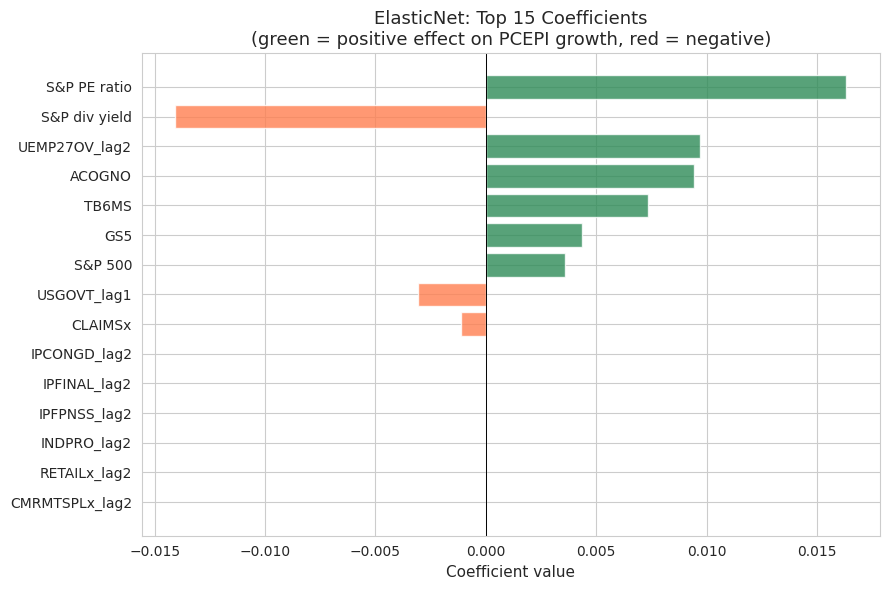

In [8]:
importance_df = elasticnet.get_feature_importance(feature_names)

if importance_df is not None:
    top15 = importance_df.head(15)
    print("Top 15 features by |ElasticNet coefficient|:")
    print(top15.to_string(index=False))

    # Signed coefficients (mapped back to full feature set; SelectKBest drops = 0)
    coef_df = importance_df[['feature', 'coefficient']].copy()
    coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)

    non_zero = (coef_df['coefficient'] != 0).sum()
    print(f"\nNon-zero coefficients: {non_zero} / {len(feature_names)}")
    print("(SelectKBest pre-filter + ElasticNet L1: zeros come from either stage)")

    signed_top15 = coef_df.head(15)
    fig, ax = plt.subplots(figsize=(9, 6))
    bar_colors = ['seagreen' if c >= 0 else 'coral' for c in signed_top15['coefficient']]
    ax.barh(signed_top15['feature'], signed_top15['coefficient'], color=bar_colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_xlabel('Coefficient value')
    ax.set_title('ElasticNet: Top 15 Coefficients\n(green = positive effect on PCEPI growth, red = negative)')
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()


In [9]:
# --- Diagnostic: PCEPI, Energy, and Food Coefficients ---
# Shows actual coefficients for series that economic theory predicts should matter,
# even if they don't appear in the top 15 by |coefficient|.
#
# Two reasons a series can be absent from the top 15:
#   (A) Its coefficient is exactly 0.0 — zeroed out by the L1 (Lasso) penalty
#   (B) Its coefficient is non-zero but smaller than the 15th-ranked feature
#
# PCEPI: after tcode-5 transformation (log-diff × 100) the level-persistence is
#   removed. Monthly *changes* in inflation are close to white noise, so
#   PCEPI_lag1 has little autocorrelation with next month's PCEPI change.
#
# Oil/Food: these are in FRED-MD but many energy/food series are also tcode-5
#   (log-diff), so the same mean-reversion applies. Additionally, with ~390
#   correlated features and only 48 training obs, ElasticNet's L1 term aggressively
#   zeros correlated series — keeping the single most predictive representative.

_estimator = elasticnet.model.named_steps['model'] if elasticnet.model is not None else None

if _estimator is not None and hasattr(_estimator, 'coef_'):
    # Map post-SelectKBest coefs back to the full feature set (zeros for dropped features)
    _selector = elasticnet.model.named_steps.get('select', None)
    _full_coef = np.zeros(len(feature_names), dtype=float)
    if _selector is not None:
        _support = _selector.get_support()
        _full_coef[_support] = _estimator.coef_
        _k_selected = int(_support.sum())
    else:
        _full_coef[:len(_estimator.coef_)] = _estimator.coef_
        _k_selected = len(feature_names)
    coef_series = pd.Series(_full_coef, index=feature_names)

    # Sparsity summary
    n_nonzero = (coef_series != 0).sum()
    print(f'SelectKBest kept {_k_selected} / {len(feature_names)} features pre-ElasticNet')
    print(f'Model sparsity: {n_nonzero} non-zero coefs post-L1 (out of {_k_selected} pre-selected, {len(feature_names)} original)')
    print(f'  ({_k_selected - n_nonzero} pre-selected features zeroed by L1; {len(feature_names) - _k_selected} dropped upstream by SelectKBest)\n')

    # Rank map (1 = largest |coef|)
    rank_map = {feat: rank + 1 for rank, feat in enumerate(coef_series.abs().sort_values(ascending=False).index)}

    # Groups of economic interest
    groups = {
        'PCEPI (target series lags)': ['PCEPI', 'PCEPI_lag1', 'PCEPI_lag2'],
        'Energy / Oil': [f for f in feature_names
                         if any(k in f.upper() for k in ['OIL', 'ENERGY', 'CPIENG', 'DCOIL'])],
        'Food / Agriculture': [f for f in feature_names
                                if any(k in f.upper() for k in ['FOOD', 'CPIUFD', 'WPSFD', 'PPIACO', 'AGRI'])],
    }

    for group_name, candidates in groups.items():
        hits = [f for f in candidates if f in coef_series.index]
        if not hits:
            print(f'[{group_name}] — no matching features found in feature set')
            continue
        print(f'[{group_name}]')
        for feat in sorted(hits, key=lambda x: rank_map[x]):
            coef   = coef_series[feat]
            rank   = rank_map[feat]
            note   = '  ← zeroed out by L1' if coef == 0.0 else ''
            print(f'  {feat:<32s}  coef = {coef:+.6f}   rank {rank:>4d} / {len(feature_names)}{note}')
        print()
else:
    print('No fitted model found — run Cell 10 first.')

SelectKBest kept 80 / 378 features pre-ElasticNet
Model sparsity: 9 non-zero coefs post-L1 (out of 80 pre-selected, 378 original)
  (71 pre-selected features zeroed by L1; 298 dropped upstream by SelectKBest)

[PCEPI (target series lags)]
  PCEPI_lag1                        coef = +0.000000   rank   63 / 378  ← zeroed out by L1
  PCEPI_lag2                        coef = +0.000000   rank  104 / 378  ← zeroed out by L1
  PCEPI                             coef = +0.000000   rank  338 / 378  ← zeroed out by L1

[Energy / Oil]
  OILPRICEx_lag1                    coef = +0.000000   rank   88 / 378  ← zeroed out by L1
  OILPRICEx_lag2                    coef = +0.000000   rank  243 / 378  ← zeroed out by L1
  OILPRICEx                         coef = +0.000000   rank  350 / 378  ← zeroed out by L1

[Food / Agriculture]
  WPSFD49502_lag1                   coef = +0.000000   rank   91 / 378  ← zeroed out by L1
  WPSFD49207_lag1                   coef = +0.000000   rank   92 / 378  ← zeroed out b

In [10]:
# Save test predictions for model_comparison.ipynb
import os
import numpy as np

os.makedirs('results', exist_ok=True)

if len(X_test) > 0:
    test_cols = [c for c in feature_names if c in X_test.columns]
    X_test_aligned = X_test[test_cols]
    _, y_pred_test = elasticnet.evaluate(X_test_aligned, y_test)
    np.save('results/elasticnet_preds.npy', y_pred_test)
    np.save('results/y_test.npy', np.array(y_test))
    np.save('results/y_test_dates.npy', np.array(y_test.index, dtype='datetime64[ns]'))
    print(f'Saved {len(y_pred_test)} test predictions to results/')
else:
    print('WARNING: No test observations to save.')


Saved 24 test predictions to results/
